# Graph Convolutional Network (GCN) development for filtered drag force modeling

### Data Preprocessing

In [ ]:
# import necessary libraries for data preprocessing and visualization
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy as sp
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Calculate terminal velocity iteratively from source code provided by (Hardy et.al, 2024) 
# Parameters for 275 micron particle 
g = 9.81            # m/s²
rho_g = 1.225       # kg/m³
rho_p = 2500        # kg/m³
mu_g = 1.8e-5       # Pa·s
dp = 275e-6         # m

def get_terminal_velocity(rho_p, rho_g, g, dp, mu_g):   
 # rho_p: density of the solid, 
 # rho_g: density of the fluid,
 # g: acceleration due to gravity,
 # dp: solid diameter
 # mu: dynamic viscosity of the fluid (gas)

 tol=1e-8
 delta= 2*tol
 count = 0
 max_count = 200
 CD=1 # drag coefficient (initialize with 1)...assumption

 while delta>tol and count<max_count:
    # calculate terminal velocity
    Ut = math.sqrt((4*dp*g*(rho_p - rho_g))/(3*CD*rho_g))
    # Reynolds number
    Ret = (rho_g*Ut*dp)/mu_g 
    
    if Ret < 1000:
        # Schiller-Naumann equation
        CD_new = (24/Ret)*(1 + 0.15*Ret**0.687) 
    else:
        CD_new = 0.44

    delta = abs(CD - CD_new)
    CD = CD_new
    count += 1
 print("Iterative process has converged in {:d} iterations".format(count))
 return Ut
Ut = get_terminal_velocity(rho_p, rho_g, g, dp, mu_g)
# Now using Ut calculate particle reynolds number and Froude number
Re_p = (rho_g * Ut * dp) / mu_g
Fr = Ut**2/(g*dp)
# Let's calculate characteristic length scale L_c
Lc = dp*Fr**(1/3)
#  similarly we calculate the terminal velocity, particle Reynolds number, Froude number and characteristic length scale for case 75 and case 300.

# -------------------------------------------------------------------------------------------------------------------------------------------------

# we have saved the large filtered data files as "pickles" for easy loading, re-loading and saving
import os
import pickle

alp_max = 0.63
rho_s   = 2500
g       = 9.81

# Group-specific constants
scaling_params = {
    "275": {"Ut": 2.026610816690855, "Lc": 0.00316358152730544},
    "300": {"Ut": 2.2232632008524815, "Lc": 0.0035660307774051875},
    "75":  {"Ut": 0.3480815707017538, "Lc": 0.000411091527800743},
}

# Paths 
raw_pickle_dir    = "./GNN_data/saved_data_pickles" # use your own path here
scaled_pickle_dir = "./GNN_data/scaled_data" # use your own path here
os.makedirs(scaled_pickle_dir, exist_ok=True)

group_files = {
    "275": "unscaled_data_275.pkl",
    "300": "unscaled_data_300.pkl",
    "75":  "unscaled_data_75.pkl"
}


for group, filename in group_files.items():
    # Load raw data
    with open(os.path.join(raw_pickle_dir, filename), "rb") as f:
        data_group = pickle.load(f)

    print(f"\nProcessing group {group}, {len(data_group)} files")

    Ut = scaling_params[group]["Ut"]
    Lc = scaling_params[group]["Lc"]

    
    for sample in data_group:
        df = sample["data"].copy()  # copy to avoid modifying original accidentally

        # Fill missing values with column mean
        df.fillna(df.mean(), inplace=True)

        # Scaling 
        df["solid-vof"]     = df["solid-vof"] / alp_max
        df["alp_vd"]        = df["alp_vd"] / (Ut * alp_max)
        df["u_slip_y"]      = df["u_slip_y"] / Ut
        df["Delta_f"]       = df["Delta_f"] / Lc
        df["dpdy_filtered"] = df["dpdy_filtered"] / (rho_s * g)
        df["fd_y"]          = df["fd_y"] / (rho_s * g)

        # Update sample
        sample["data"] = df
        sample["scaled"] = True
        sample["meta"] = {"Ut": Ut, "Lc": Lc, "alp_max": alp_max}

    # --- Save scaled pickle ---
    scaled_filename = f"scaled_data_{group}_dict.pkl"
    with open(os.path.join(scaled_pickle_dir, scaled_filename), "wb") as f:
        pickle.dump(data_group, f)

### GCN

In [9]:
# import libraries for GCN model
import pickle
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Load the scaled data Pickle files and create PyTorch Geometric datasets

In [10]:
# use your own path here
with open("./GNN_data/scaled_data/scaled_data_275_dict.pkl", "rb") as f: 
    scaled_data_275 = pickle.load(f)
with open("./GNN_data/scaled_data/scaled_data_300_dict.pkl", "rb") as f:
    scaled_data_300 = pickle.load(f)
with open("./GNN_data/scaled_data/scaled_data_75_dict.pkl", "rb") as f: 
    scaled_data_75 = pickle.load(f)

In [11]:
data = scaled_data_275 + scaled_data_300 + scaled_data_75
ny, nx = 450, 224
N= ny* nx
print("Total graph samples:", len(data))

feature_cols = ['solid-vof', 'u_slip_y','dpdy_filtered']
label_cols   = ['alp_vd']

Total graph samples: 252


In [17]:
graphs = []
for sample in data:
    df = sample["data"]
    X = df[feature_cols].values.reshape(ny,nx,-1)
    y = df[label_cols].values.reshape(ny,nx,-1)
    graphs.append({
        "case": sample["folder"],
        "filename": sample["filename"],
        "X_grid": X,
        "y_grid": y
    })

# print("Graphs prepared:", len(graphs))
for g in graphs:
    X_flat = g["X_grid"].reshape(-1, g["X_grid"].shape[2]) # 100800 x 5 
    y_flat = g["y_grid"].reshape(-1, 1) # 100800 x 1
    g["X_flat"] = X_flat 
    g["y_flat"] = y_flat
# create edge index for each graph
def build_undirected_grid_edges(ny, nx):
    edges = []

    for i in range(ny):
        for j in range(nx):
            node_id = i * nx + j

            forward_neighbors = [
                (i, j+1),     # right
                (i+1, j),     # down
                (i+1, j+1),   # down-right
                (i+1, j-1)    # down-left
            ]

            for ni, nj in forward_neighbors:
                if 0 <= ni < ny and 0 <= nj < nx:
                    neighbor_id = ni * nx + nj
                    edges.append([node_id, neighbor_id])

    # Mirror edges to make undirected
    edge_list = edges.copy()
    for a, b in edges:
        edge_list.append([b, a])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

# Example usage
ny, nx = 450, 224
edge_index = build_undirected_grid_edges(ny, nx)
# print("Edge index shape:", edge_index.shape)  

    
train_graphs = [g for g in graphs if "t1" in g["filename"] or "t2" in g["filename"]]
test_graphs  = [g for g in graphs if "t3" in g["filename"]]

print("Train graphs:", len(train_graphs))
print("Test graphs:", len(test_graphs))

Train graphs: 168
Test graphs: 84


In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv

class GCNRegressor(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 128)  
        self.conv2 = GCNConv(128, 64)          
        self.conv3 = GCNConv(64, 8)             
        self.lin   = nn.Linear(8, 1)            

    def forward(self, x, edge_index):
        h = torch.relu(self.conv1(x, edge_index))
        h = torch.relu(self.conv2(h, edge_index))
        h = torch.relu(self.conv3(h, edge_index))
        out = self.lin(h)
        return h, out
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=GCNRegressor(in_channels=len(feature_cols)).to(device)

# Prepare PyG Data objects
train_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in train_graphs
]
test_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in test_graphs
]

GCNRegressor(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(64, 8)
  (lin): Linear(in_features=8, out_features=1, bias=True)
)


### Reload the saved model without retraining the model

In [ ]:
# Load the saved best model for inference/testing.
# run the notebook starting after the GCN markdown section without k-fold training loop.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCNRegressor(in_channels=3).to(device)
checkpoint = torch.load("final_3_marker_gcn_DF_model_updated.pt",
    map_location=device,
    weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model.eval()

GCNRegressor(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(64, 8)
  (lin): Linear(in_features=8, out_features=1, bias=True)
)

### Apply best fold model on test graph set and visualize predictions vs true values

In [21]:
from torch_geometric.loader import DataLoader  

test_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in test_graphs
]

test_loader = DataLoader(test_data_objects, batch_size=1, shuffle=False)

test_y_true, test_y_pred = [], []
test_embeddings = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        h, pred = model(batch.x, batch.edge_index)
        test_embeddings.append(h.cpu())
        test_y_true.append(batch.y.cpu().numpy())
        test_y_pred.append(pred.cpu().numpy())

test_y_true = np.vstack(test_y_true)
test_y_pred = np.vstack(test_y_pred)

mse = mean_squared_error(test_y_true, test_y_pred)
mae = mean_absolute_error(test_y_true, test_y_pred)
r2 = r2_score(test_y_true, test_y_pred)



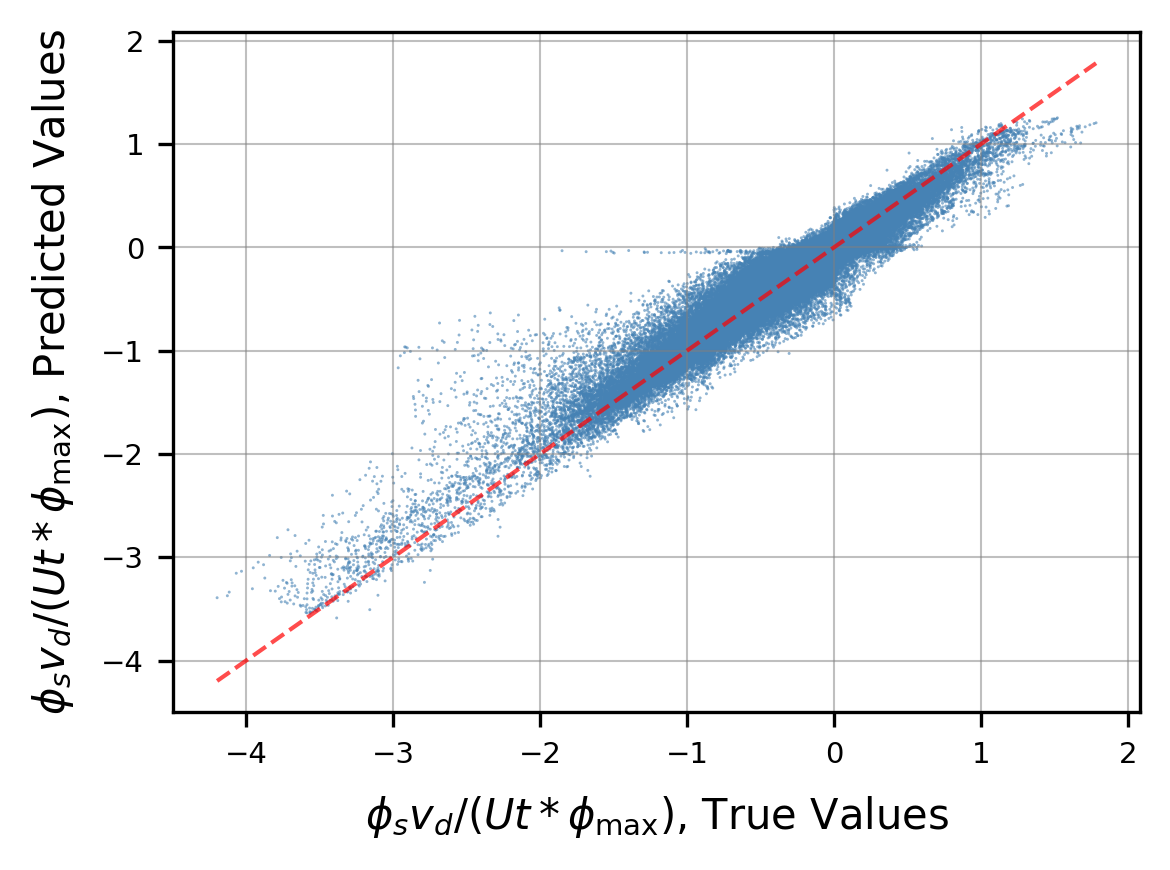

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

y_true = test_y_true.flatten()
y_pred = test_y_pred.flatten()

plt.figure(figsize=(4, 3), dpi=300, facecolor='white')
plt.scatter(y_true, y_pred, 
            s=0.5,
            alpha=0.6, 
            c='steelblue',
            edgecolors='none')

plt.plot([y_true.min(), y_true.max()], 
         [y_true.min(), y_true.max()], 
         'r--', 
         lw=1,
         alpha=0.7)

plt.xlabel(r"$\phi_s v_d / (Ut* \phi_{\mathrm{max}})$, True Values", 
           fontsize=10, labelpad=6)
plt.ylabel(r"$\phi_s v_d / (Ut* \phi_{\mathrm{max}})$, Predicted Values", 
           fontsize=10, labelpad=6)

plt.grid(True, linestyle='-', color='gray', alpha=0.5, linewidth=0.5)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
r2 = r2_score(y_true, y_pred)
plt.tight_layout()
plt.show()

### Filter Drag force calculation based on drift flux model

In [ ]:
graphs_test = []

for sample in data:
    if "t3" in sample["filename"]:   
        df = sample["data"]
        
        # Print the 'alp_vd' column
        # print(df['fd_y'])
        
        X = df[feature_cols].values.reshape(ny, nx, -1)
        y = df[label_cols].values.reshape(ny, nx, -1)
        X_flat = X.reshape(-1, X.shape[2])
        y_flat = y.reshape(-1, 1)

        graphs_test.append({
            "X_flat": X_flat,
            "y_flat": y_flat,
            "df": df,              
            "filename": sample["filename"]
        })
fd_true = []

for g in graphs_test:  # graphs_test "t3" files
    fd_true.append(g['df']['fd_y'].values)  
# Combine all arrays into one
fd_true = np.hstack(fd_true)

alp_max = 0.63
g = 9.81

# Flatten quantities for all graphs into 1D arrays
Ut_all      = np.hstack([g["df"]["ut"].values for g in graphs_test])
alp_all     = np.hstack([g["df"]["solid-vof"].values for g in graphs_test]) * alp_max
u_slip_all  = np.hstack([g["df"]["u_slip_y"].values for g in graphs_test]) * Ut_all
tau_p_all   = np.hstack([g["df"]["tau_p_tilde"].values for g in graphs_test])

alp_vd_physical_all = test_y_pred.flatten() * Ut_all*alp_max

# Compute drag force elementwise
fd_model_all_true = (alp_all * u_slip_all + alp_vd_physical_all) / (tau_p_all * g)

fd_true = np.round(fd_true, 2)
fd_model_all_true = np.round(fd_model_all_true, 2)
r2_fd = r2_score(fd_true, fd_model_all_true)
# print(f"R² between fd_model_all_true and fd_true: {r2_fd:.2f}")